
# PFAS BDE PREDICTION - PRODUCTION NOTEBOOK

"""
This notebook provides a simple interface for predicting Bond Dissociation 
Energies (BDEs) of PFAS molecules using a pre-trained XGBoost model.

USAGE:
1. Load your molecule data (CSV with SMILES and solvent info)
2. Fragment molecules into bonds (creates Parent_PFAS dictionary)
3. Run predictions to get BDEs for all bonds
4. View visualizations with BDEs labeled on molecular structures

MODEL PERFORMANCE:
- MAE:  1.611 ± 0.265 kcal/mol
- RMSE: 3.423 ± 0.698 kcal/mol
- R²:   0.946 ± 0.018
- Training set: ~701 bonds from both gas and water solvent phase PFAS
- DFT level: ωB97X-V/def2-TZVPD

REQUIREMENTS:
- xgboost_bde_model_optimized.pkl (trained model)
- solvent_encoder.pkl (solvent encoder)
- bde_utils.py (helper functions)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle
import warnings
import json
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Import custom utility functions
from bde_utils import (
    smiles_to_fp,
    predict_bde,
    canonicalize_smiles,
    make_sorted_pair,
    remove_dummy_atoms_and_add_radicals,
    dedupe_bonds,
    fragment_molecules,
    convert_parent_pfas_to_dataframe,
    show_image_grid,
    show_image_grid_save
)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("="*80)
print("PFAS BDE PREDICTION TOOL")
print("="*80)
print("✓ Libraries imported successfully")
print("✓ Utility functions loaded from bde_utils.py")
print("="*80)


PFAS BDE PREDICTION TOOL
✓ Libraries imported successfully
✓ Utility functions loaded from bde_utils.py


In [4]:
# ============================================================================
# STEP 1: LOAD PRE-TRAINED MODEL
# ============================================================================
print("\n" + "="*80)
print("STEP 1: LOADING PRE-TRAINED MODEL")
print("="*80)

try:
    print("\nLoading model files...")

    with open('ML_Models/xgboost_bde_model_optimized.pkl', 'rb') as f:
        model = pickle.load(f)

    with open('ML_Models/solvent_encoder.pkl', 'rb') as f:
        solvent_encoder = pickle.load(f)

    # ── NEW: load confidence artifacts ────────────────────────────────────
    with open('ML_Models/training_fps.pkl', 'rb') as f:
        training_fps = pickle.load(f)

    with open('ML_Models/model_metadata.json', 'r') as f:
        model_metadata = json.load(f)

    conformal_quantile_90 = model_metadata['confidence']['conformal_quantile_90']
    domain_threshold      = model_metadata['confidence']['domain_threshold']
    # ─────────────────────────────────────────────────────────────────────

    print("✓ Model loaded:              xgboost_bde_model_optimized.pkl")
    print("✓ Encoder loaded:            solvent_encoder.pkl")
    print("✓ Training FPs loaded:       training_fps.pkl")      # ← NEW
    print("✓ Confidence metadata loaded: model_metadata.json")  # ← NEW

    print(f"\n{'─'*80}")
    print("MODEL DETAILS")
    print(f"{'─'*80}")
    print(f"  Type:              {type(model).__name__}")
    print(f"  Input features:    6,148 (Parent FP + Frag1 FP + Frag2 FP + Solvent)")
    print(f"  Fingerprint type:  Morgan (ECFP4, radius=2, 2048 bits)")
    print(f"  Solvent encoding:  One-hot (gas/water)")

    # ── NEW: print confidence summary ─────────────────────────────────────
    print(f"\n{'─'*80}")
    print("CONFIDENCE DETAILS")
    print(f"{'─'*80}")
    c = model_metadata['confidence']
    print(f"  90% prediction interval:  ±{c['conformal_quantile_90']:.3f} kcal/mol")
    print(f"  80% prediction interval:  ±{c['conformal_quantile_80']:.3f} kcal/mol")
    print(f"  Calibration samples:      {c['n_calibration_samples']}")
    print(f"  Domain threshold:         {c['domain_threshold']:.3f} (Tanimoto)")
    # ─────────────────────────────────────────────────────────────────────

    print(f"\n{'='*80}")
    print("✓ MODEL READY FOR PREDICTIONS")
    print("="*80)

except FileNotFoundError as e:
    print("\n" + "="*80)
    print("❌ ERROR: REQUIRED FILES NOT FOUND")
    print("="*80)
    print("\nMissing files:")
    print("  Required:")
    print("    • xgboost_bde_model_optimized.pkl")
    print("    • solvent_encoder.pkl")
    print("    • training_fps.pkl")       # ← NEW
    print("    • model_metadata.json")    # ← NEW
    print("\nPlease ensure these files are in the ML_Models/ directory.")
    print("="*80)
    raise


STEP 1: LOADING PRE-TRAINED MODEL

Loading model files...
✓ Model loaded:              xgboost_bde_model_optimized.pkl
✓ Encoder loaded:            solvent_encoder.pkl
✓ Training FPs loaded:       training_fps.pkl
✓ Confidence metadata loaded: model_metadata.json

────────────────────────────────────────────────────────────────────────────────
MODEL DETAILS
────────────────────────────────────────────────────────────────────────────────
  Type:              XGBRegressor
  Input features:    6,148 (Parent FP + Frag1 FP + Frag2 FP + Solvent)
  Fingerprint type:  Morgan (ECFP4, radius=2, 2048 bits)
  Solvent encoding:  One-hot (gas/water)

────────────────────────────────────────────────────────────────────────────────
CONFIDENCE DETAILS
────────────────────────────────────────────────────────────────────────────────
  90% prediction interval:  ±2.713 kcal/mol
  80% prediction interval:  ±1.458 kcal/mol
  Calibration samples:      701
  Domain threshold:         0.438 (Tanimoto)

✓ MODEL

In [6]:
# ============================================================================
# USER INPUT: Specify your data file
# ============================================================================

# Option 1: CSV file
data_file = "Data/Test_ML.csv"




STEP 2: LOADING MOLECULAR DATA

Attempting to load: Data/Test_ML.csv
✓ CSV file loaded successfully
  Rows: 3
  Columns: ['SMILES', 'solvent']

────────────────────────────────────────────────────────────────────────────────
VALIDATING DATA FORMAT
────────────────────────────────────────────────────────────────────────────────
✓ Required columns found
✓ Optional column 'solvent' found
⚠ Optional column 'name' not found

────────────────────────────────────────────────────────────────────────────────
PARSING MOLECULAR STRUCTURES
────────────────────────────────────────────────────────────────────────────────

Processing 3 SMILES strings...

────────────────────────────────────────────────────────────────────────────────
PARSING RESULTS
────────────────────────────────────────────────────────────────────────────────
  ✓ Successfully parsed:  3 molecules
  ✗ Failed to parse:      0 molecules

✓ Final dataset: 3 valid molecules

────────────────────────────────────────────────────────────

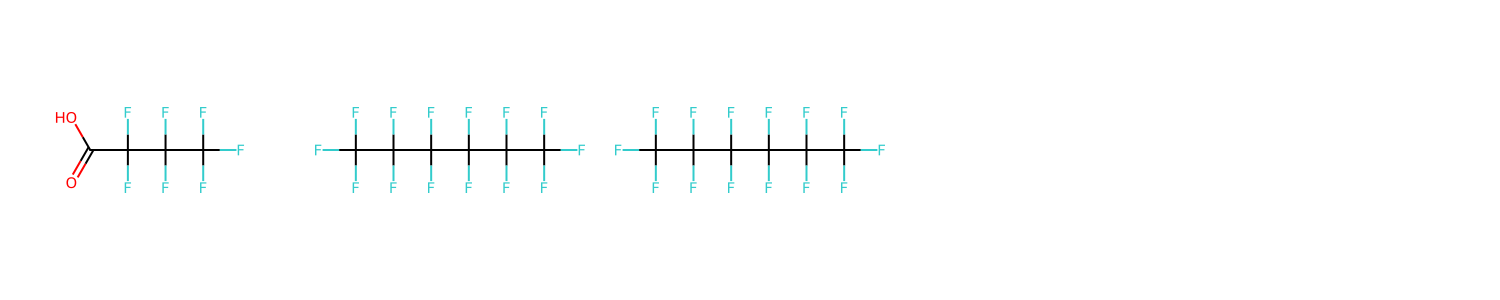


✓ DATA LOADING COMPLETE


In [7]:
# ============================================================================
# STEP 2: LOAD USER DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 2: LOADING MOLECULAR DATA")
print("="*80)

# ============================================================================

print(f"\nAttempting to load: {data_file}")

# Detect file type and load accordingly
try:
    if data_file.endswith('.csv'):
        df = pd.read_csv(data_file)
        print(f"✓ CSV file loaded successfully")
    elif data_file.endswith(('.xlsx', '.xls')):
        df = pd.read_excel(data_file)
        print(f"✓ Excel file loaded successfully")
    else:
        raise ValueError("File must be .csv, .xlsx, or .xls format")
    
    print(f"  Rows: {len(df)}")
    print(f"  Columns: {list(df.columns)}")
    
except FileNotFoundError:
    print(f"\n❌ ERROR: File not found: {data_file}")
    print("   Please check the file path and try again.")
    raise
except Exception as e:
    print(f"\n❌ ERROR: Could not load file")
    print(f"   {str(e)}")
    raise

# ============================================================================
# Validate required columns
# ============================================================================

print(f"\n{'─'*80}")
print("VALIDATING DATA FORMAT")
print(f"{'─'*80}")

required_columns = ['SMILES']
optional_columns = ['solvent', 'name']

# Check for required columns
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    print(f"\n❌ ERROR: Missing required column(s): {missing_required}")
    print(f"   Your columns: {list(df.columns)}")
    print(f"\n   Required format:")
    print(f"     - SMILES: Parent molecule SMILES strings")
    print(f"   Optional:")
    print(f"     - solvent: 'gas' or 'water' (defaults to 'gas')")
    print(f"     - name: Molecule names for reference")
    raise ValueError(f"Missing required columns: {missing_required}")

print("✓ Required columns found")

# Check for optional columns
for col in optional_columns:
    if col in df.columns:
        print(f"✓ Optional column '{col}' found")
    else:
        print(f"⚠ Optional column '{col}' not found")
        if col == 'solvent':
            print(f"  → Will default all molecules to 'gas' phase")

# Add default solvent if not present
if 'solvent' not in df.columns:
    df['solvent'] = 'gas'
    print(f"✓ Added default solvent column (all set to 'gas')")

# ============================================================================
# Parse and canonicalize SMILES
# ============================================================================

print(f"\n{'─'*80}")
print("PARSING MOLECULAR STRUCTURES")
print(f"{'─'*80}")

smiles_list = df["SMILES"].dropna().tolist()
print(f"\nProcessing {len(smiles_list)} SMILES strings...")

bad_smiles = []
mols = []
smiles_canonical = []

for idx, smiles in enumerate(smiles_list):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            canonical = Chem.MolToSmiles(mol)
            smiles_canonical.append(canonical)
            mols.append(mol)
        else:
            bad_smiles.append((idx, smiles))
    except Exception as e:
        bad_smiles.append((idx, smiles))

print(f"\n{'─'*80}")
print("PARSING RESULTS")
print(f"{'─'*80}")
print(f"  ✓ Successfully parsed:  {len(mols)} molecules")
print(f"  ✗ Failed to parse:      {len(bad_smiles)} molecules")

if bad_smiles:
    print(f"\n⚠ Warning: {len(bad_smiles)} SMILES could not be parsed:")
    for idx, smiles in bad_smiles[:5]:  # Show first 5
        print(f"    Row {idx}: {smiles[:60]}...")
    if len(bad_smiles) > 5:
        print(f"    ... and {len(bad_smiles) - 5} more")
    print(f"\n  These molecules will be skipped in predictions.")

# Update dataframe with canonical SMILES
df = df[df["SMILES"].isin(smiles_list)]  # Keep only valid rows
df['SMILES_Canonical'] = df['SMILES'].apply(canonicalize_smiles)
df = df[df['SMILES_Canonical'].notna()]  # Remove failed canonicalizations

print(f"\n✓ Final dataset: {len(df)} valid molecules")

# ============================================================================
# Visualize loaded molecules
# ============================================================================

if len(mols) > 0:
    print(f"\n{'─'*80}")
    print("MOLECULAR STRUCTURES")
    print(f"{'─'*80}")
    
    # Create molecule grid
    max_display = min(len(mols), 20)  # Show up to 20 molecules
    
    if 'name' in df.columns:
        legends = df['name'].head(max_display).tolist()
    else:
        legends=''
    
    grid = Draw.MolsToGridImage(
        mols[:max_display],
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=legends,
        useSVG=False
    )
    
    display(grid)
    
    if len(mols) > max_display:
        print(f"\n(Showing first {max_display} of {len(mols)} molecules)")

print("\n" + "="*80)
print("✓ DATA LOADING COMPLETE")
print("="*80)

In [8]:
# ============================================================================
# STEP 3: FRAGMENT MOLECULES INTO BONDS
# ============================================================================

Parent_PFAS = fragment_molecules(smiles_canonical)
# ============================================================================
# STEP 4: PREPARE BOND DATA FOR PREDICTION
# ============================================================================

df_user = convert_parent_pfas_to_dataframe(Parent_PFAS, df)

In [14]:
print(f"\n✓ Converted {len(df_user)} bonds from {len(Parent_PFAS)} unique parent molecules")

print(f"\nDataframe structure:")
print(df_user.head())

print(f"\nSolvent distribution and bond counts (duplicate bonds are removed):")
print(df_user['solvent'].value_counts())

print(f"\nUnique parent molecules: {df_user['Parent_SMILES'].nunique()}")
print(f"Unique parent + solvent combinations: {df_user.groupby(['Parent_SMILES', 'solvent']).ngroups}")

print("="*80)


✓ Converted 20 bonds from 2 unique parent molecules

Dataframe structure:
                  Parent_SMILES                    Frag1_SMILES  \
0  O=C(O)C(F)(F)C(F)(F)C(F)(F)F     O=[C]C(F)(F)C(F)(F)C(F)(F)F   
1  O=C(O)C(F)(F)C(F)(F)C(F)(F)F                       [H]O[C]=O   
2  O=C(O)C(F)(F)C(F)(F)C(F)(F)F  [H]OC(=O)[C](F)C(F)(F)C(F)(F)F   
3  O=C(O)C(F)(F)C(F)(F)C(F)(F)F                [H]OC(=O)[C](F)F   
4  O=C(O)C(F)(F)C(F)(F)C(F)(F)F  [H]OC(=O)C(F)(F)[C](F)C(F)(F)F   

             Frag2_SMILES solvent  Bond_ID  
0                  [H][O]     gas        1  
1  F[C](F)C(F)(F)C(F)(F)F     gas        2  
2                     [F]     gas        3  
3         F[C](F)C(F)(F)F     gas        5  
4                     [F]     gas        6  

Solvent distribution and bond counts (duplicate bonds are removed):
solvent
gas      14
water     6
Name: count, dtype: int64

Unique parent molecules: 2
Unique parent + solvent combinations: 3


In [34]:
# ============================================================================
# STEP 5: GENERATE BDE PREDICTIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 5: GENERATING BDE PREDICTIONS")
print("="*80)
print(f"\nPredicting BDEs for {len(df_user)} bonds...")
df_user = df_user.reset_index(drop=True)  # ← NEW: fix index alignment

predictions    = []
lower_bounds   = []   # ← NEW
upper_bounds   = []   # ← NEW
in_domain_list = []   # ← NEW
ad_scores      = []   # ← NEW

skipped_count  = 0
failed_count   = 0
out_of_domain  = 0    # ← NEW

# ── NEW: helper — Tanimoto AD check ──────────────────────────────────────────
def check_applicability_domain(parent_smiles, frag1_smiles, frag2_smiles, solvent, training_fps, threshold, radius=2, nBits=2048):
    """
    Build a concatenated fingerprint (parent + frag1 + frag2 + solvent) matching
    the training feature format exactly (6145 bits), then compute mean Tanimoto
    similarity to the 5 nearest neighbors in the training set.
    Returns (mean_sim, in_domain).
    """
    from rdkit import DataStructs
    from rdkit.DataStructs import CreateFromBitString

    bits = []
    for smi in [parent_smiles, frag1_smiles, frag2_smiles]:
        mol = Chem.MolFromSmiles(smi) if smi else None
        if mol is None:
            bits.extend([0] * nBits)
        else:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
            bits.extend(fp.ToList())

    # Append solvent bit to match training feature format (6145 bits total)
    bits.append(1 if solvent == 'water' else 0)

    query_fp = CreateFromBitString("".join(str(b) for b in bits))
    sims = DataStructs.BulkTanimotoSimilarity(query_fp, training_fps)
    top5 = sorted(sims, reverse=True)[:5]
    mean_score = float(np.mean(top5))
    return mean_score, bool(mean_score >= threshold)
# ─────────────────────────────────────────────────────────────────────────────

for idx, row in df_user.iterrows():
    try:
        # Skip ring bonds (empty Frag2)
        if row['Frag2_SMILES'] == '':
            predictions.append(np.nan)
            lower_bounds.append(np.nan)
            upper_bounds.append(np.nan)
            in_domain_list.append(np.nan)
            ad_scores.append(np.nan)
            skipped_count += 1
            continue

        # Predict BDE
        pred = predict_bde(
            row['Parent_SMILES'],
            row['Frag1_SMILES'],
            row['Frag2_SMILES'],
            row['solvent'],
            model,
            solvent_encoder
        )
        predictions.append(pred)

        # ── NEW: conformal interval ───────────────────────────────────────
        lower_bounds.append(pred - conformal_quantile_90)
        upper_bounds.append(pred + conformal_quantile_90)

        # ── NEW: applicability domain check ──────────────────────────────
        ad_score, in_dom = check_applicability_domain(
            row['Parent_SMILES'], row['Frag1_SMILES'], row['Frag2_SMILES'],
            row['solvent'], training_fps, domain_threshold
        )
        in_domain_list.append(in_dom)
        ad_scores.append(ad_score)
        if not in_dom:
            out_of_domain += 1
        # ─────────────────────────────────────────────────────────────────

    except Exception as e:
        predictions.append(np.nan)
        lower_bounds.append(np.nan)
        upper_bounds.append(np.nan)
        in_domain_list.append(np.nan)
        ad_scores.append(np.nan)
        failed_count += 1

# Add predictions to dataframe
df_user['Predicted_BDE']  = predictions
df_user['BDE_Lower_90']   = lower_bounds    # ← NEW
df_user['BDE_Upper_90']   = upper_bounds    # ← NEW
df_user['In_Domain']      = in_domain_list  # ← NEW
df_user['AD_Score']       = ad_scores       # ← NEW

# Summary
successful = df_user['Predicted_BDE'].notna().sum()
total      = len(df_user)

print(f"\n{'─'*80}")
print("PREDICTION RESULTS")
print(f"{'─'*80}")
print(f"  ✓ Successful predictions:  {successful}/{total}")
if skipped_count > 0:
    print(f"  ⊘ Skipped (ring bonds):    {skipped_count}")
if failed_count > 0:
    print(f"  ✗ Failed predictions:      {failed_count}")

# ── NEW: domain summary ───────────────────────────────────────────────────────
in_dom_count = sum(1 for v in in_domain_list if v is True)
print(f"\n  📊 Applicability Domain:")
print(f"     In domain:     {in_dom_count}/{successful} bonds")
print(f"     Out of domain: {out_of_domain}/{successful} bonds")
if out_of_domain > 0:
    print(f"     ⚠ Out-of-domain predictions are flagged — interpret with caution")
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("✓ PREDICTIONS COMPLETE")
print("="*80)


STEP 5: GENERATING BDE PREDICTIONS

Predicting BDEs for 20 bonds...

────────────────────────────────────────────────────────────────────────────────
PREDICTION RESULTS
────────────────────────────────────────────────────────────────────────────────
  ✓ Successful predictions:  20/20

  📊 Applicability Domain:
     In domain:     20/20 bonds
     Out of domain: 0/20 bonds

✓ PREDICTIONS COMPLETE


[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerator
[17:58:28] DEPRECATION WARNING: please use MorganGenerat


STEP 6: CREATING MOLECULAR VISUALIZATIONS

Generating molecule images with BDE labels on bonds...
✓ Created visualizations for 3 molecule-solvent combinations

────────────────────────────────────────────────────────────────────────────────
DISPLAYING MOLECULAR STRUCTURES
────────────────────────────────────────────────────────────────────────────────

════════════════════════════════════════════════════════════════════════════════
GAS PHASE - 2 molecule(s)
════════════════════════════════════════════════════════════════════════════════



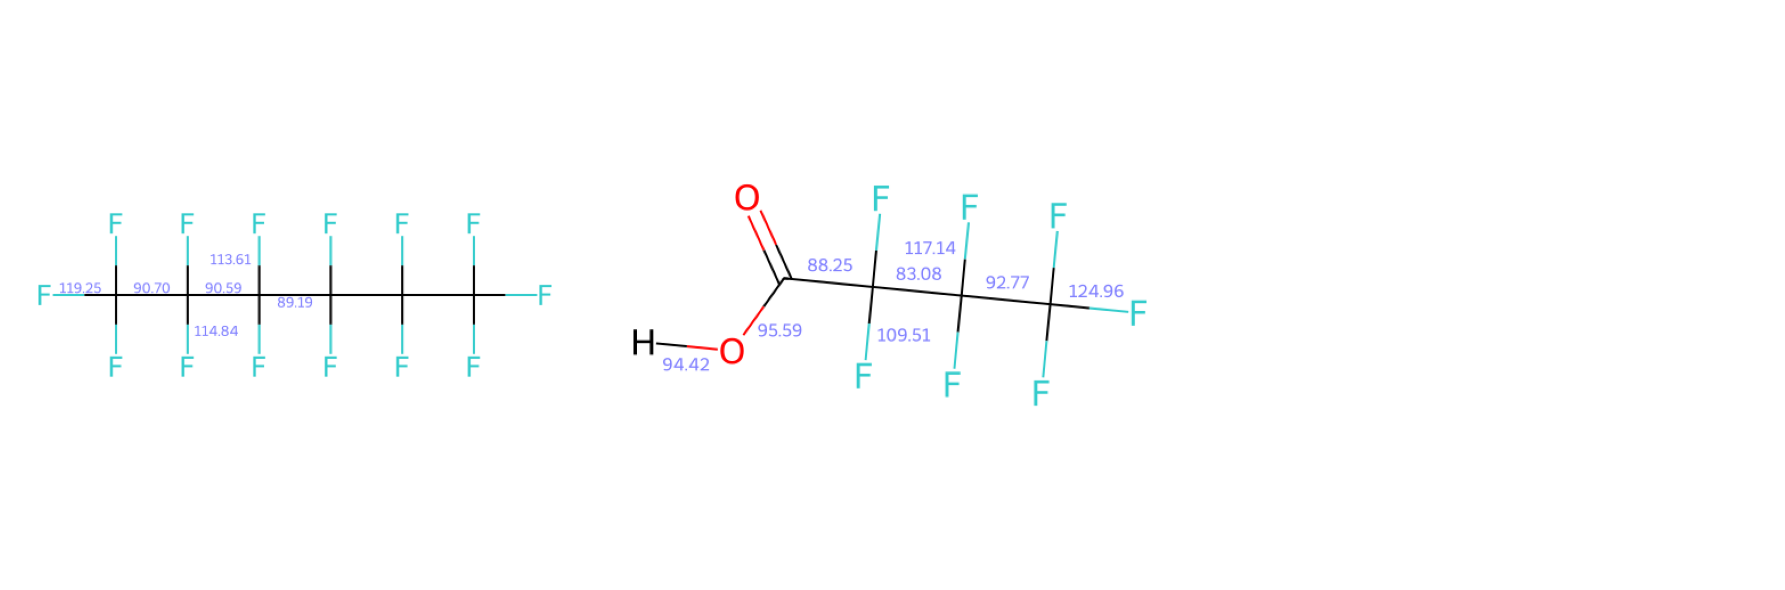


════════════════════════════════════════════════════════════════════════════════
WATER PHASE - 1 molecule(s)
════════════════════════════════════════════════════════════════════════════════



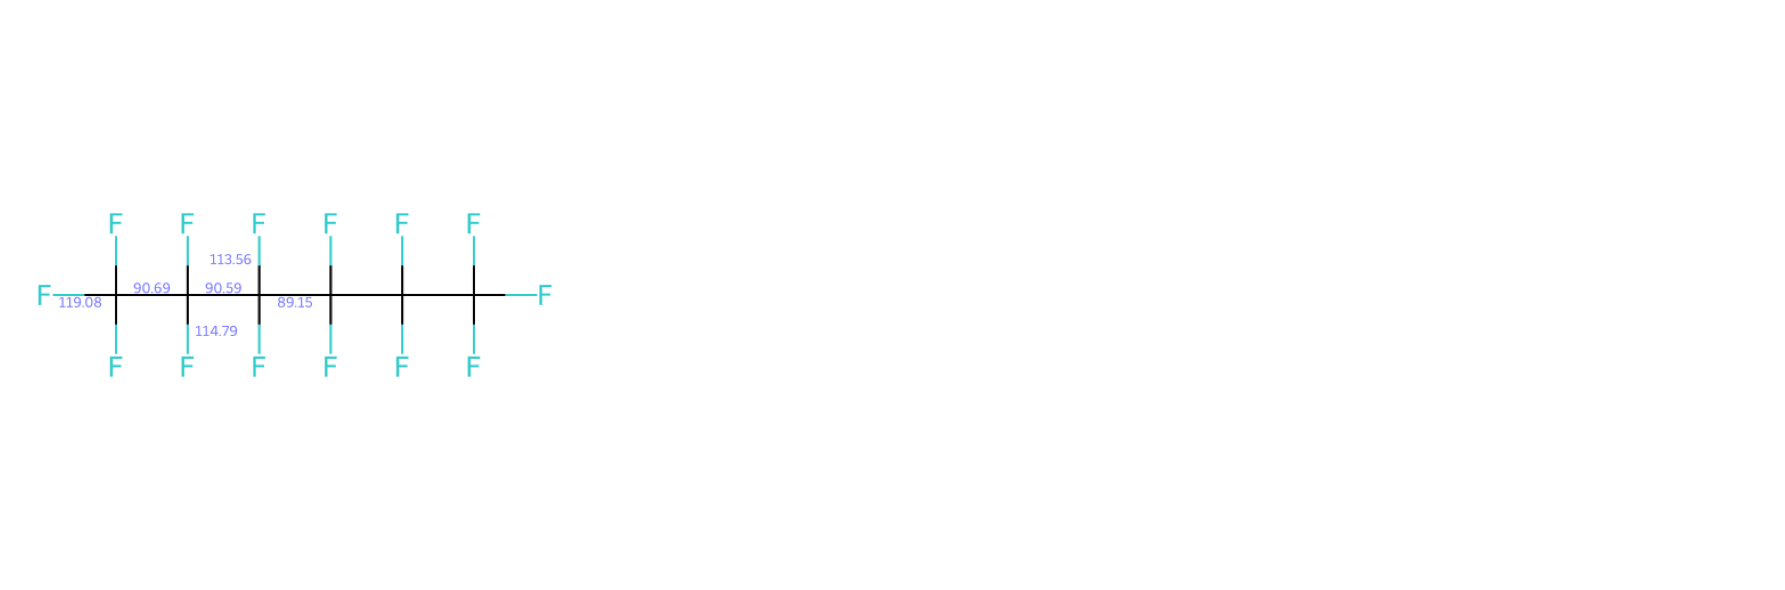


✓ VISUALIZATIONS COMPLETE


In [38]:
# ============================================================================
# STEP 6: VISUALIZE MOLECULES WITH BDE LABELS
# ============================================================================

print("\n" + "="*80)
print("STEP 6: CREATING MOLECULAR VISUALIZATIONS")
print("="*80)

print("\nGenerating molecule images with BDE labels on bonds...")

# Group images by solvent
image_maps = {}  # {solvent: {molecule_name: image}}

for (parent_smiles, solvent), group_df in df_user.groupby(['Parent_SMILES', 'solvent']):
    # Create molecule
    mol = Chem.MolFromSmiles(parent_smiles)
    if mol is None:
        continue
    
    mol = Chem.AddHs(mol)
    Chem.rdDepictor.Compute2DCoords(mol)
    
    # Label each bond with its predicted BDE
    for idx, row in group_df.iterrows():
        if pd.notna(row['Predicted_BDE']):
            bde = row['Predicted_BDE']
            bond_idx = int(row['Bond_ID'])
            mol.GetBondWithIdx(bond_idx).SetProp('bondNote', f"{bde:.2f}")
    
    # Draw molecule
    img = Draw.MolToImage(mol, size=(500, 500), atomLabels=False)
    
    # Store in solvent-specific dictionary
    if solvent not in image_maps:
        image_maps[solvent] = {}
    
    molecule_label = parent_smiles[:40] + '...' if len(parent_smiles) > 40 else parent_smiles
    image_maps[solvent][molecule_label] = img

print(f"✓ Created visualizations for {sum(len(imgs) for imgs in image_maps.values())} molecule-solvent combinations")

# ============================================================================
# Display images grouped by solvent
# ============================================================================

print(f"\n{'─'*80}")
print("DISPLAYING MOLECULAR STRUCTURES")
print(f"{'─'*80}\n")

for solvent in sorted(image_maps.keys()):
    print(f"{'═'*80}")
    print(f"{solvent.upper()} PHASE - {len(image_maps[solvent])} molecule(s)")
    print(f"{'═'*80}\n")
    
    images = list(image_maps[solvent].values())
    labels = [""] * len(images)  # Empty labels (SMILES shown in title if needed)
    
    show_image_grid(images, labels, mols_per_row=3)
    
    print()  # Spacing between solvents

print("="*80)
print("✓ VISUALIZATIONS COMPLETE")
print("="*80)


In [39]:
df_user

,Parent_SMILES,Frag1_SMILES,Frag2_SMILES,solvent,Bond_ID,Predicted_BDE,BDE_Lower_90,BDE_Upper_90,In_Domain,AD_Score
0,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,O=[C]C(F)(F)C(F)(F)C(F)(F)F,[H][O],gas,1,95.588455,92.875404,98.301507,True,0.487674
1,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,[H]O[C]=O,F[C](F)C(F)(F)C(F)(F)F,gas,2,88.247070,85.534019,90.960122,True,0.760311
2,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,[H]OC(=O)[C](F)C(F)(F)C(F)(F)F,[F],gas,3,109.510223,106.797172,112.223275,True,0.760311
3,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,[H]OC(=O)[C](F)F,F[C](F)C(F)(F)F,gas,5,83.082787,80.369735,85.795838,True,0.735874
4,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,[H]OC(=O)C(F)(F)[C](F)C(F)(F)F,[F],gas,6,117.144295,114.431243,119.857346,True,0.729172
5,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,[H]OC(=O)C(F)(F)[C](F)F,F[C](F)F,gas,8,92.772423,90.059371,95.485474,True,0.754835
6,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,[H]OC(=O)C(F)(F)C(F)(F)[C](F)F,[F],gas,9,124.960609,122.247558,127.673661,True,0.777340
7,O=C(O)C(F)(F)C(F)(F)C(F)(F)F,[O]C(=O)C(F)(F)C(F)(F)C(F)(F)F,[H],gas,12,94.415482,91.702430,97.128533,True,0.812756
8,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,[F],F[C](F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,water,0,119.077377,116.364326,121.790429,True,0.594146
9,FC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,F[C](F)F,F[C](F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,water,3,90.694458,87.981407,93.407509,True,0.600925


# Export Results

In [40]:
output_file='bde_predictions.csv'
output_image_prefix = "molecules_bde"  # Will create molecules_bde_gas.png, molecules_bde_water.png, etc.

In [41]:
# Save results table
print(f"\nSaving results to: {output_file}")

try:
    if output_file.endswith('.csv'):
        df_user.to_csv(output_file, index=False)
        print(f"✓ Results saved as CSV")
    elif output_file.endswith(('.xlsx', '.xls')):
        df_user.to_excel(output_file, index=False)
        print(f"✓ Results saved as Excel")
    else:
        raise ValueError("Output file must be .csv, .xlsx, or .xls format")
    
    print(f"  File: {output_file}")
    print(f"  Rows: {len(df_user)}")
    
except Exception as e:
    print(f"\n❌ ERROR: Failed to save results file")
    print(f"   {str(e)}")
    raise

# Save molecular images (they're already created in image_maps)
# Save molecular images
if output_image_prefix:
    print(f"\nSaving molecular visualizations...")
    saved_images = []
    
    for solvent in sorted(image_maps.keys()):
        filename = f"{output_image_prefix}_{solvent}.png"
        
        images = list(image_maps[solvent].values())
        labels = [""] * len(images)
        
        fig = show_image_grid_save(images, labels, mols_per_row=3)
        
        if fig:
            fig.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close(fig)
            saved_images.append(filename)
            print(f"  ✓ {filename}")
    
    print(f"✓ Saved {len(saved_images)} image file(s)")
else:
    print(f"\n⊘ Image saving skipped (output_image_prefix not set)")




Saving results to: bde_predictions.csv
✓ Results saved as CSV
  File: bde_predictions.csv
  Rows: 20

Saving molecular visualizations...
  ✓ molecules_bde_gas.png
  ✓ molecules_bde_water.png
✓ Saved 2 image file(s)


## Comparing to DFT results
compares to gas phase dft results

In [23]:
# ============================================================================
# COMPARE PREDICTIONS TO DFT GROUND TRUTH
# ============================================================================
print("\n" + "="*80)
print("COMPARING PREDICTIONS TO DFT CALCULATIONS")
print("="*80)

# Reset df_user if running multiple times
if 'BDE_wB97X-V' in df_user.columns:
    print("⚠️  Comparison already run - resetting df_user...")
    # Remove the comparison columns if they exist
    cols_to_drop = ['BDE_wB97X-V', 'BDE_Anion', 'Error', 'Absolute_Error', 'Frag_Pair', 'DFT_Source']
    df_user = df_user.drop(columns=[c for c in cols_to_drop if c in df_user.columns])

# Load both DFT datasets
df_dft_neutral = pd.read_csv("Data/Enthalpy_Neutral_BDE_table.csv")
df_dft_neutral = df_dft_neutral.dropna()
df_dft_neutral['DFT_Source'] = 'Neutral'

df_dft_anion = pd.read_csv("Data/Enthalpy_Anion_BDE_table.csv")  # Adjust filename if needed
df_dft_anion = df_dft_anion.dropna()
df_dft_anion['DFT_Source'] = 'Anion'

print(f"\nLoaded DFT data:")
print(f"  Neutral: {len(df_dft_neutral)} bonds")
print(f"  Anion:   {len(df_dft_anion)} bonds")

print("\nCanonicalizing SMILES...")

# Canonicalize df_user (only if not already done)
if 'Parent_Canon' not in df_user.columns:
    df_user['Parent_Canon'] = df_user['Parent_SMILES'].apply(canonicalize_smiles)
    df_user['Frag1_Canon'] = df_user['Frag1_SMILES'].apply(canonicalize_smiles)
    df_user['Frag2_Canon'] = df_user['Frag2_SMILES'].apply(canonicalize_smiles)

# Canonicalize both DFT datasets
for df_dft in [df_dft_neutral, df_dft_anion]:
    df_dft['Parent_Canon'] = df_dft['Parent_SMILES'].apply(canonicalize_smiles)
    df_dft['Frag1_Canon'] = df_dft['Frag1_SMILES'].apply(canonicalize_smiles)
    df_dft['Frag2_Canon'] = df_dft['Frag2_SMILES'].apply(canonicalize_smiles)
    df_dft['Frag_Pair'] = df_dft.apply(lambda x: make_sorted_pair(x['Frag1_Canon'], x['Frag2_Canon']), axis=1)

# Create fragment pairs for user data
df_user['Frag_Pair'] = df_user.apply(lambda x: make_sorted_pair(x['Frag1_Canon'], x['Frag2_Canon']), axis=1)

# Combine both DFT datasets
df_dft_combined = pd.concat([df_dft_neutral, df_dft_anion], ignore_index=True)

# Merge on parent + sorted fragment pair
df_comparison = df_user.merge(
    df_dft_combined[['Parent_Canon', 'Frag_Pair', 'BDE_wB97X-V', 'DFT_Source']],
    on=['Parent_Canon', 'Frag_Pair'],
    how='left'
)

# Calculate errors where we have ground truth
if 'BDE_wB97X-V' in df_comparison.columns:
    df_comparison['Error'] = df_comparison['BDE_wB97X-V'] - df_comparison['Predicted_BDE']
    df_comparison['Absolute_Error'] = df_comparison['Error'].abs()
    
    # Count matches
    n_matches = df_comparison['BDE_wB97X-V'].notna().sum()
    n_neutral = (df_comparison['DFT_Source'] == 'Neutral').sum()
    n_anion = (df_comparison['DFT_Source'] == 'Anion').sum()
    
    print(f"\n✓ Found {n_matches} matching bonds in DFT data:")
    print(f"    Neutral: {n_neutral}")
    print(f"    Anion:   {n_anion}")
    
    if n_matches > 0:
        # Show comparison
        print("\n" + "="*80)
        print("PREDICTION vs DFT COMPARISON")
        print("="*80)
        
        matched_df = df_comparison[df_comparison['BDE_wB97X-V'].notna()].copy()
        
        print(f"\n{'Bond':<6} {'Source':<8} {'Parent (short)':<30} {'DFT BDE':<12} {'Predicted':<12} {'Error':<10}")
        print("-"*95)
        
        for idx, row in matched_df.head(20).iterrows():
            parent_short = row['Parent_SMILES'][:28] + '...' if len(row['Parent_SMILES']) > 28 else row['Parent_SMILES']
            source = row['DFT_Source']
            print(f"{idx:<6} {source:<8} {parent_short:<30} {row['BDE_wB97X-V']:<12.2f} {row['Predicted_BDE']:<12.2f} {row['Error']:<+10.2f}")
        
        if len(matched_df) > 20:
            print(f"... ({len(matched_df) - 20} more rows)")
        
        # Summary statistics - Overall
        print("\n" + "="*80)
        print("ACCURACY METRICS - OVERALL")
        print("="*80)
        
        mae = matched_df['Absolute_Error'].mean()
        rmse = np.sqrt((matched_df['Error']**2).mean())
        
        print(f"\nMean Absolute Error (MAE):  {mae:.3f} kcal/mol")
        print(f"Root Mean Squared Error:    {rmse:.3f} kcal/mol")
        print(f"Mean Error (bias):          {matched_df['Error'].mean():+.3f} kcal/mol")
        print(f"Max Absolute Error:         {matched_df['Absolute_Error'].max():.3f} kcal/mol")
        
        # Summary statistics - By source
        if n_neutral > 0:
            print("\n" + "-"*80)
            print("NEUTRAL BONDS ONLY")
            print("-"*80)
            neutral_df = matched_df[matched_df['DFT_Source'] == 'Neutral']
            print(f"MAE:  {neutral_df['Absolute_Error'].mean():.3f} kcal/mol")
            print(f"RMSE: {np.sqrt((neutral_df['Error']**2).mean()):.3f} kcal/mol")
            print(f"Bias: {neutral_df['Error'].mean():+.3f} kcal/mol")
        
        if n_anion > 0:
            print("\n" + "-"*80)
            print("ANION BONDS ONLY")
            print("-"*80)
            anion_df = matched_df[matched_df['DFT_Source'] == 'Anion']
            print(f"MAE:  {anion_df['Absolute_Error'].mean():.3f} kcal/mol")
            print(f"RMSE: {np.sqrt((anion_df['Error']**2).mean()):.3f} kcal/mol")
            print(f"Bias: {anion_df['Error'].mean():+.3f} kcal/mol")
        
        
        
    else:
        print("\n⚠ No matching bonds found in DFT data")
        print("  Your test molecules may not be in the training set")
else:
    print("\n⚠ No matching bonds found - BDE_wB97X-V column not created")

print("="*80)

# Store comparison
df_user = df_comparison


COMPARING PREDICTIONS TO DFT CALCULATIONS
⚠️  Comparison already run - resetting df_user...

Loaded DFT data:
  Neutral: 418 bonds
  Anion:   283 bonds

Canonicalizing SMILES...

✓ Found 8 matching bonds in DFT data:
    Neutral: 8
    Anion:   0

PREDICTION vs DFT COMPARISON

Bond   Source   Parent (short)                 DFT BDE      Predicted    Error     
-----------------------------------------------------------------------------------------------
0      Neutral  O=C(O)C(F)(F)C(F)(F)C(F)(F)F   113.62       95.59        +18.04    
1      Neutral  O=C(O)C(F)(F)C(F)(F)C(F)(F)F   88.79        88.25        +0.54     
2      Neutral  O=C(O)C(F)(F)C(F)(F)C(F)(F)F   108.92       109.51       -0.59     
3      Neutral  O=C(O)C(F)(F)C(F)(F)C(F)(F)F   83.09        83.08        +0.01     
4      Neutral  O=C(O)C(F)(F)C(F)(F)C(F)(F)F   117.60       117.14       +0.45     
5      Neutral  O=C(O)C(F)(F)C(F)(F)C(F)(F)F   93.19        92.77        +0.42     
6      Neutral  O=C(O)C(F)(F)C(F)(F)C

[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not removing hydrogen atom without neighbors
[13:17:36] WARNING: not r